## 6.2 양자 센싱 (Quantum Sensing)

In [1]:
# 필요한 라이브러리 불러오기
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [2]:
# 자기장을 센싱하는 양자 회로를 만드는 함수
def magnetic_field_sensor(theta):
    # 큐비트 1개로 양자 회로 생성
    qc = QuantumCircuit(1, 1)

    # 하다마드 게이트로 중첩 상태 생성
    qc.h(0)

    # 각도 theta만큼 Y축 회전 적용
    qc.ry(theta, 0)

    # 또 다른 하다마드 게이트
    qc.h(0)

    # 큐비트 측정
    qc.measure(0, 0)

    return qc

In [3]:
# 센싱할 자기장 파라미터(theta)
theta = np.pi / 4  # 예: 자기장 세기

In [4]:
# 양자 회로 생성
qc = magnetic_field_sensor(theta)

Quantum Circuit for Magnetic Field Sensing:


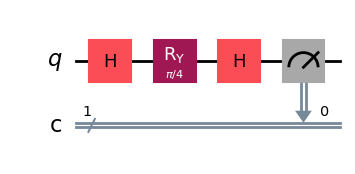

In [5]:
# 컴파일 전 양자 회로 그리기
print("Quantum Circuit for Magnetic Field Sensing:")
qc.draw('mpl')
plt.show()

In [6]:
# 시뮬레이터 선택
simulator = AerSimulator()

In [7]:
# 시뮬레이터용으로 회로 트랜스파일
compiled_circuit = transpile(qc, simulator)


Compiled Quantum Circuit for Magnetic Field Sensing:


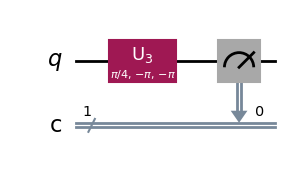

In [8]:
# 컴파일 후 양자 회로 그리기
print("\nCompiled Quantum Circuit for Magnetic Field Sensing:")
compiled_circuit.draw('mpl')
plt.show()

In [9]:
# 회로 시뮬레이션
result = simulator.run(compiled_circuit, shots=1000).result()

In [10]:
# 카운트(측정 결과) 추출
counts = result.get_counts()
print("\nMeasurement results (counts):")
print(counts)


Measurement results (counts):
{'1': 150, '0': 850}


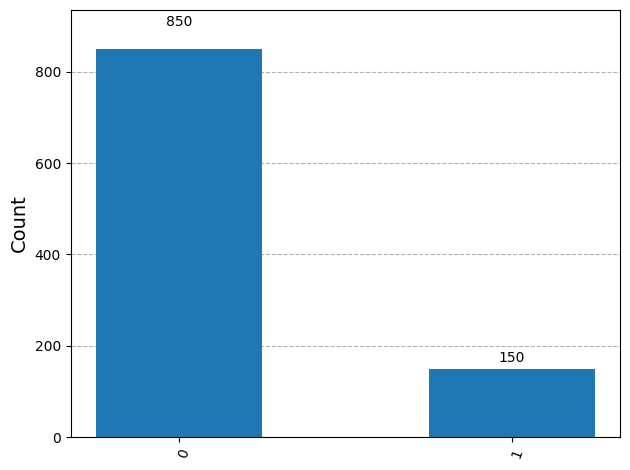

In [11]:
# 결과 히스토그램 그리기
plot_histogram(counts)
plt.show()